# 06 — D6 `garch_t_vol`: GJR-GARCH(1,1)-t + umbral causal de sigma

Familia **F5 (Volatilidad)**. Detector univariante sobre el **retorno log del S&P 500**
(desde 1985). El modelo **GJR-GARCH(1,1)-t** no produce *estados tipados*: produce una
**sigma condicional** (volatilidad esperada de t dado el pasado). El régimen se define
**umbralizando** esa sigma con un percentil del train (histéresis τ_in/τ_out + dwell).

**Por qué GJR-GARCH-t:** `o=1` capta la **asimetría / leverage** (las caídas suben la
vol futura más que las subidas — Glosten-Jagannathan-Runkle 1993); `dist='t'` capta las
**colas gordas** (kurtosis 25–40 del EDA — Bollerslev 1987); base GARCH(1,1) (Bollerslev
1986) sobre el ARCH de Engle (1982). Escala ×100 recomendada por `arch` (Sheppard).

## Hipótesis CP2 (la que este notebook pone a prueba)
> *"El GARCH **no da estados tipados**; se **umbraliza la sigma**. Es **causal por
> construcción** y **reacciona EL MISMO DÍA** que llega el shock (sigma_t salta con el
> retorno de t), así que **DEBERÍA captar también las correcciones rápidas de 2013
> (taper) y 2018 (Q4)** donde el HMM gaussiano (D4) se queda corto. Univariante sobre
> equity."*

**Ventana LARGA:** al modelar solo el S&P 500 (desde 1985), el walk-forward cubre
**2008 y 2011 OUT-OF-SAMPLE** — algo que D4 (atado a HYG desde 2007) no podía.

## Índice

D6 es un notebook de **volatilidad condicional**: todo gira en torno a una única señal
continua, la **sigma del GJR-GARCH-t**, y a cómo se umbraliza en régimen. El recorrido
encadena tres preguntas — *(i)* ¿qué hay dentro del modelo (leverage γ, colas-t ν)?,
*(ii)* ¿es causal la sigma?, *(iii)* ¿el umbral separa de verdad calma de crisis y
reacciona a tiempo? Mapa navegable:

1. [Ajuste in-sample: parámetros del GJR-GARCH-t y umbral de sigma](#sec1)
   - 1.1 [Efecto leverage GJR — *news impact curve* (la asimetría γ, vista)](#sec1-1)
   - 1.2 [Colas-t: QQ-plot de residuos estandarizados (t vs Normal)](#sec1-2)
2. [Verificación de CAUSALIDAD de la sigma (burn-in + parámetros congelados)](#sec2)
3. [Versión CAUSAL walk-forward (la comparable; cubre 2008 y 2011 OOS)](#sec3)
4. [Sigma condicional con umbral y ventanas de crisis](#sec4)
   - 4.1 [Distribución de la sigma POR régimen (calma vs crisis, con el umbral)](#sec4-1)
   - 4.2 [Sigma condicional vs volatilidad realizada (¿mide lo que dice medir?)](#sec4-2)
5. [S&P 500 coloreado por régimen (CAUSAL OOS)](#sec5)
6. [Verificación contra eventos: crisis 2008/2011/2020/2022 y trampas 2013/2018](#sec6)
7. [Timeline de régimen y duraciones (flickering)](#sec7)
8. [Volcado de métricas (esquema canónico 32 columnas)](#sec8)
9. [Conclusión D6 — ¿se cumple la hipótesis CP2?](#sec9)

**Figuras.** Existentes: `d06_sigma_threshold`, `d06_sp500_regimes`, `d06_coverage`,
`d06_timeline`. Nuevas (ampliación Ola 1, mecanismo del modelo): `d06_leverage_news_impact`
(curva de impacto de noticias / asimetría γ), `d06_residuals_qq` (QQ-plot t vs Normal que
justifica las colas-t), `d06_sigma_dist_by_regime` (la sigma separada por régimen con el
umbral marcado) y `d06_sigma_vs_realized` (sigma condicional contra volatilidad realizada).

In [1]:
%matplotlib inline
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
warnings.filterwarnings('ignore')
ROOT = Path.cwd()
while not (ROOT / 'src').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
RESULTS = ROOT / 'results'; RESULTS.mkdir(exist_ok=True)
from src import evaluation as ev
from src import viz
viz.use_house_style()                            # rcParams homogéneos (estilo de casa)
from detectors.garch_t_vol import GarchTVol

raw = pd.read_parquet(ROOT / 'data' / 'raw' / 'raw_panel.parquet')
spx_ret = np.log(raw['SP500'] / raw['SP500'].shift(1)).rename('SP500_ret')
X = pd.DataFrame({'SP500_ret': spx_ret}).dropna()
X.index = pd.to_datetime(X.index); X = X.sort_index()
mkt = X['SP500_ret']                              # market_returns (S&P 500 log-ret)
sp500 = raw['SP500'].reindex(X.index)
print('X (histórico largo):', X.shape, '|', X.index.min().date(), '->', X.index.max().date())
print('OBLIGATORIO pasar market_returns a walk_forward Y evaluate (señal = sigma, no retorno).')

X (histórico largo): (10294, 1) | 1985-01-03 -> 2026-06-12
OBLIGATORIO pasar market_returns a walk_forward Y evaluate (señal = sigma, no retorno).


<a id="sec1"></a>
## 1. Ajuste in-sample: parámetros del GJR-GARCH-t y umbral de sigma

Ajuste sobre toda la muestra (solo para inspeccionar el modelo y la sigma; la
clasificación comparable es la **causal** de §3). El orden económico (0=calma · 1=crisis)
lo fija `label_states_economically` con el retorno del S&P 500.

In [2]:
det_is = GarchTVol().fit(X)
det_is.label_states_economically(X, market_returns=mkt)   # orden económico con S&P 500
p = det_is._params
print('GJR-GARCH(1,1)-t  (retornos x100):')
for k in ['mu','omega','alpha[1]','gamma[1]','beta[1]','nu']:
    print(f'  {k:9s} = {float(p[k]):+.4f}')
print(f'\n  gamma[1] > 0  -> leverage (las caidas elevan mas la vol)  [GJR]')
print(f'  nu = {float(p["nu"]):.2f}  -> colas gordas (t de Student)')
print(f'\ntau_in (p{int(det_is.q_in*100)} sigma train)  = {det_is._tau_in:.3f}')
print(f'tau_out (p{int(det_is.q_out*100)} sigma train) = {det_is._tau_out:.3f}')
print(f'logL = {det_is.score(X):.1f} | n_params = {det_is.n_parameters()} | '
      f'AIC = {det_is.aic(X):.1f} | BIC = {det_is.bic(X):.1f}')

# sigma condicional in-sample (escala x100) y estados in-sample
sigma_is = det_is._conditional_sigma(X)
states_is = pd.Series(det_is.predict(X), index=X.index, name='state')

# VERIFICACION CRITICA: crisis canonico = ALTA sigma (no invertido)
sig_cri = sigma_is[states_is.values == det_is.crisis_state].mean()
sig_cal = sigma_is[states_is.values == 0].mean()
print(f'\nVERIFICACION etiquetado: sigma media CRISIS={sig_cri:.3f}  vs  CALMA={sig_cal:.3f}')
assert sig_cri > sig_cal, 'INVERTIDO: crisis deberia ser ALTA sigma'
print(f'OK -> crisis (estado canonico {det_is.crisis_state}) = ALTA sigma. No invertido.')

GJR-GARCH(1,1)-t  (retornos x100):


  mu        = +0.0592
  omega     = +0.0193
  alpha[1]  = +0.0103
  gamma[1]  = +0.1619
  beta[1]   = +0.8898
  nu        = +6.1053

  gamma[1] > 0  -> leverage (las caidas elevan mas la vol)  [GJR]
  nu = 6.11  -> colas gordas (t de Student)

tau_in (p80 sigma train)  = 1.243
tau_out (p60 sigma train) = 0.933
logL = -13285.6 | n_params = 6 | AIC = 26583.1 | BIC = 26626.6

VERIFICACION etiquetado: sigma media CRISIS=1.593  vs  CALMA=0.742
OK -> crisis (estado canonico 1) = ALTA sigma. No invertido.


<a id="sec1-1"></a>
### 1.1 Efecto leverage GJR — *news impact curve* (la asimetría γ, vista)

El término que separa al GJR-GARCH de un GARCH simétrico es **γ (`gamma[1]`)**. La ecuación
de varianza es

$$\sigma^2_{t} = \omega + \big(\alpha + \gamma\,\mathbb{1}[\varepsilon_{t-1}<0]\big)\,\varepsilon_{t-1}^2 + \beta\,\sigma^2_{t-1},$$

de modo que un **shock negativo** del mismo tamaño que uno positivo eleva la varianza
futura con coeficiente **(α+γ)** en vez de solo **α**: es el *efecto apalancamiento*
(las caídas asustan más que lo que tranquilizan las subidas — Glosten-Jagannathan-Runkle
1993, Engle-Ng 1993). La **curva de impacto de noticias** lo hace visible: fijamos
$\sigma^2_{t-1}$ en su nivel **incondicional** $\bar{\sigma}^2=\omega/(1-\alpha-\beta-\gamma/2)$
y dibujamos la sigma del día siguiente, $\sigma_{t}$, frente al shock $\varepsilon_{t-1}$.
La rama de shocks **negativos** (roja) queda por encima de la de positivos (azul); como
referencia, la curva **simétrica** (γ=0, gris) muestra cuánta vol extra añade el leverage.

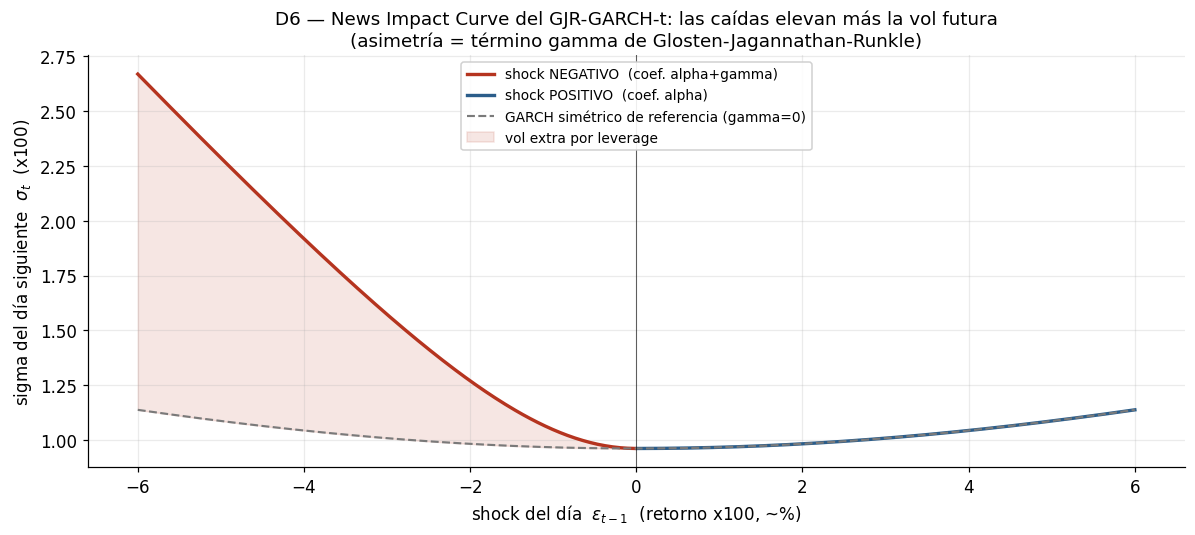

alpha=0.0103  gamma=0.1619  beta=0.8898
persistencia (alpha+beta+gamma/2) = 0.9810  -> vol muy persistente (<1 = estacionaria)
asimetría: un shock NEGATIVO pesa (alpha+gamma)/alpha = 16.75x lo que pesa uno positivo del mismo tamaño
OK -> gamma > 0: leverage confirmado (caídas elevan más la vol que subidas)


In [3]:
p = det_is._params
omega = float(p['omega']); alpha = float(p['alpha[1]'])
gamma = float(p['gamma[1]']); beta = float(p['beta[1]'])

# Varianza incondicional implícita (innovaciones simétricas -> E[1{eps<0}] = 0.5).
persist = alpha + beta + 0.5 * gamma
sig2_bar = omega / max(1e-9, (1.0 - persist))

eps = np.linspace(-6.0, 6.0, 400)                       # shock en unidades x100 (~%)
base = omega + beta * sig2_bar                          # parte fija (omega + beta*sigma2_bar)
nic_gjr = base + (alpha + gamma * (eps < 0)) * eps**2   # GJR (asimétrica)
nic_sym = base + alpha * eps**2                         # GARCH simétrico (gamma=0) de referencia
sig_gjr = np.sqrt(nic_gjr); sig_sym = np.sqrt(nic_sym)

fig, ax = plt.subplots(figsize=(11, 5))
neg = eps < 0
ax.plot(eps[neg], sig_gjr[neg], color=viz.C_CRISIS, lw=2.2, label='shock NEGATIVO  (coef. alpha+gamma)')
ax.plot(eps[~neg], sig_gjr[~neg], color=viz.C_LONG, lw=2.2, label='shock POSITIVO  (coef. alpha)')
ax.plot(eps, sig_sym, color=viz.C_NEG, lw=1.4, ls='--', label='GARCH simétrico de referencia (gamma=0)')
ax.axvline(0.0, color='black', lw=0.7, alpha=0.6)
ax.fill_between(eps[neg], sig_sym[neg], sig_gjr[neg], color=viz.C_CRISIS, alpha=0.12,
                label='vol extra por leverage')
ax.set_xlabel('shock del día  $\\varepsilon_{t-1}$  (retorno x100, ~%)')
ax.set_ylabel('sigma del día siguiente  $\\sigma_t$  (x100)')
ax.set_title('D6 — News Impact Curve del GJR-GARCH-t: las caídas elevan más la vol futura\n'
             '(asimetría = término gamma de Glosten-Jagannathan-Runkle)')
ax.legend(loc='upper center', fontsize=9, framealpha=0.9)
fig.tight_layout(); fig.savefig(RESULTS / 'd06_leverage_news_impact.png', dpi=110, bbox_inches='tight'); plt.show()

ratio = (alpha + gamma) / alpha if alpha > 0 else float('nan')
print(f'alpha={alpha:.4f}  gamma={gamma:.4f}  beta={beta:.4f}')
print(f'persistencia (alpha+beta+gamma/2) = {persist:.4f}  -> vol muy persistente (<1 = estacionaria)')
print(f'asimetría: un shock NEGATIVO pesa (alpha+gamma)/alpha = {ratio:.2f}x lo que pesa uno positivo del mismo tamaño')
if gamma > 0:
    print('OK -> gamma > 0: leverage confirmado (caídas elevan más la vol que subidas)')

<a id="sec1-2"></a>
### 1.2 Colas-t: QQ-plot de los residuos estandarizados (t de Student vs Normal)

La segunda decisión de diseño de D6 es `dist='t'` en vez de gaussiano. La justificación se
ve en los **residuos estandarizados** $z_t=(\varepsilon_t-\mu)/\sigma_t$: si el GARCH ha
absorbido bien la heterocedasticidad, lo que queda son innovaciones i.i.d. cuya forma
revela las **colas**. El QQ-plot enfrenta los cuantiles empíricos de $z_t$ contra los de
una **Normal** (panel izquierdo) y contra una **t de Student con ν grados de libertad
estimados** (panel derecho, estandarizada a varianza unidad). Bajo la Normal, los puntos se
**despegan en los extremos** (las observaciones extremas son mucho más probables de lo que
una gaussiana admite — las caídas de 1987/2008/2020); bajo la t, se **alinean sobre la
diagonal**. Es la evidencia directa de por qué Bollerslev (1987) introdujo la t: un GARCH
gaussiano subestimaría sistemáticamente la probabilidad de los días de pánico.

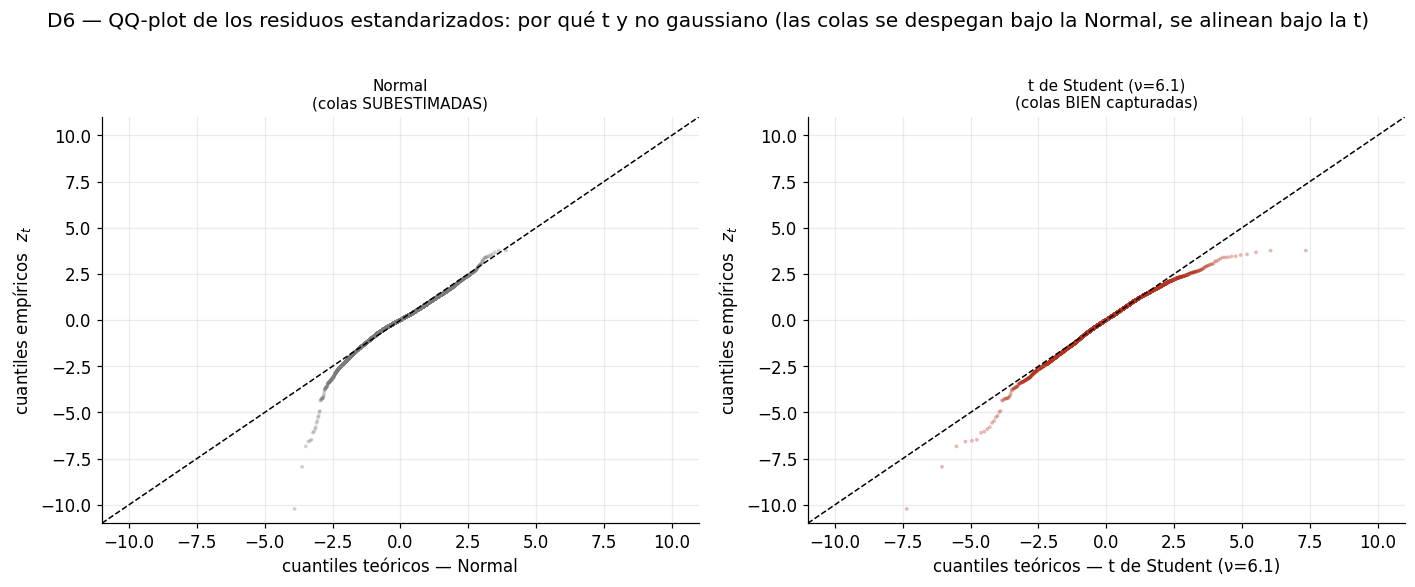

nu (grados de libertad t) = 6.11  -> colas tanto más gordas cuanto menor nu
exceso de curtosis de los residuos estandarizados = +3.51  (0 = gaussiano; >0 = colas pesadas)
Lectura: el panel Normal se curva en S en los extremos; el panel t pega sobre la diagonal.


In [4]:
import scipy.stats as ss
mu = float(det_is._params['mu']); nu = float(det_is._params['nu'])
r_scaled = (mkt * det_is.scale).reindex(sigma_is.index)
z = ((r_scaled - mu) / sigma_is).dropna().sort_values().values   # residuos estandarizados
n = len(z)
pp = (np.arange(1, n + 1) - 0.5) / n
q_norm = ss.norm.ppf(pp)
q_t = ss.t.ppf(pp, df=nu) / np.sqrt(nu / (nu - 2.0))             # t estandarizada (var=1)

fig, (axN, axT) = plt.subplots(1, 2, figsize=(13, 5.2))
lim = float(np.ceil(max(np.abs(z).max(), np.abs(q_t).max())))
for ax, q, name, col, ok in [
        (axN, q_norm, 'Normal',           viz.C_NEG,    'colas SUBESTIMADAS'),
        (axT, q_t,    f't de Student (ν={nu:.1f})', viz.C_CRISIS, 'colas BIEN capturadas')]:
    ax.scatter(q, z, s=6, alpha=0.35, color=col, edgecolors='none')
    ax.plot([-lim, lim], [-lim, lim], color='black', lw=1.0, ls='--')
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_xlabel(f'cuantiles teóricos — {name}')
    ax.set_ylabel('cuantiles empíricos  $z_t$')
    ax.set_title(f'{name}\n({ok})', fontsize=10)
fig.suptitle('D6 — QQ-plot de los residuos estandarizados: por qué t y no gaussiano '
             '(las colas se despegan bajo la Normal, se alinean bajo la t)', y=1.02)
fig.tight_layout(); fig.savefig(RESULTS / 'd06_residuals_qq.png', dpi=110, bbox_inches='tight'); plt.show()

exk = float(ss.kurtosis(z, fisher=True))
print(f'nu (grados de libertad t) = {nu:.2f}  -> colas tanto más gordas cuanto menor nu')
print(f'exceso de curtosis de los residuos estandarizados = {exk:+.2f}  (0 = gaussiano; >0 = colas pesadas)')
print('Lectura: el panel Normal se curva en S en los extremos; el panel t pega sobre la diagonal.')

<a id="sec2"></a>
## 2. Verificación de CAUSALIDAD de la sigma

La sigma de GARCH es causal nativa, pero el walk-forward no debe reestimar con el test.
La sigma del bloque se computa con **parámetros congelados** sobre `[burn-in train] +
bloque` (`.fix`). Test: ocultar el futuro NO debe cambiar la sigma del bloque.

In [5]:
det_c = GarchTVol().fit(X.loc[:'2007-12-31'])
block = X.loc['2008-01-01':'2008-12-31']
sig_block = det_c._conditional_sigma(block)
sig_plus  = det_c._conditional_sigma(X.loc['2008-01-01':'2010-12-31']).loc[sig_block.index]
maxdiff = float((sig_block - sig_plus).abs().max())
print(f'max |sigma_bloque(ver futuro) - sigma_bloque(ocultar futuro)| = {maxdiff:.2e}')
assert maxdiff < 1e-9, 'La sigma del bloque NO es causal'
print('causal_ok = True  -> sigma_t usa solo retornos <= t (burn-in propaga la recursion)')

max |sigma_bloque(ver futuro) - sigma_bloque(ocultar futuro)| = 0.00e+00
causal_ok = True  -> sigma_t usa solo retornos <= t (burn-in propaga la recursion)


<a id="sec3"></a>
## 3. Versión CAUSAL walk-forward (la comparable)

`ev.walk_forward` reentrena el GJR-GARCH-t en ventanas **expanding** (train inicial
**8 años**) y predice el bloque de `step=21` días con parámetros congelados. **Se pasa
`market_returns=mkt`** para re-fijar el orden económico de estados de forma robusta (la
señal es sigma, no retorno → sin esto el etiquetado podría invertirse).

In [6]:
TRAIN_SIZE = 252 * 8   # ~8 anios: 2008 y 2011 caen OOS (histórico largo desde 1985)
STEP = 21
panel = ev.walk_forward(lambda: GarchTVol(), X, market_returns=mkt,
                        train_size=TRAIN_SIZE, step=STEP, expanding=True)
print('OOS:', panel.index.min().date(), '->', panel.index.max().date(), '| n_oos =', len(panel))
states_c = panel['state']; p_c = panel['p_crisis']

# Detector ajustado a TODA la muestra solo para logL/AIC/BIC; clasificacion = panel OOS
res = ev.evaluate(det_is, panel, market_returns=mkt, X_full=X)
res.detector_name = 'garch_t_vol'
print('ventana_eval:', res.extra['ventana_eval'])
print('\nCobertura de crisis (CAUSAL OOS):')
for k, v in res.crisis_coverage.items(): print(f'  {k:16s}: {v:6.1%}')
print('Falsas alarmas en ventanas TRAMPA (CAUSAL OOS):')
for k, v in res.false_alarm_in_fp.items(): print(f'  {k:16s}: {v:6.1%}')
print(f'\nfalse_alarm_rate = {res.false_alarm_rate:.3f} | switching = {res.switching_rate:.4f} '
      f'| dur media = {res.mean_regime_duration:.1f} d | label_stability = {res.label_stability:.3f}')

OOS: 1993-03-23 -> 2026-06-12 | n_oos = 8278


ventana_eval: 1993-03-23→2026-06-12 (n=8278)

Cobertura de crisis (CAUSAL OOS):
  GFC_2008        : 100.0%
  EuroDebt_2011   :  74.1%
  COVID_2020      :  94.0%
  Inflation_2022  :  80.4%
Falsas alarmas en ventanas TRAMPA (CAUSAL OOS):
  TaperTantrum_2013:  11.3%
  Selloff_Q4_2018 :  87.3%

false_alarm_rate = 0.845 | switching = 0.0141 | dur media = 70.2 d | label_stability = 0.999


<a id="sec4"></a>
## 4. Sigma condicional con umbral y ventanas de crisis

Sigma condicional in-sample (escala ×100, vol diaria en %) con el umbral τ_in. Bandas
rojas = ventanas de crisis conocidas; naranjas = trampas (2013/2018).

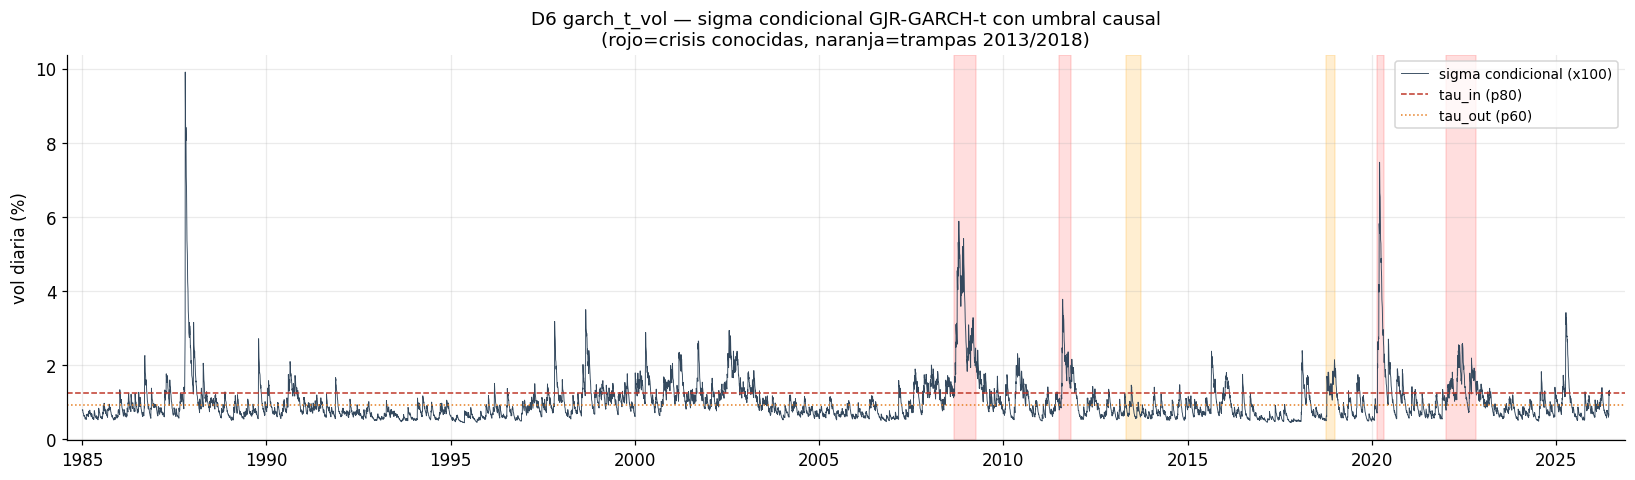

In [7]:
fig, ax = plt.subplots(figsize=(15, 4.5))
ax.plot(sigma_is.index, sigma_is.values, color='#34495e', lw=0.6, label='sigma condicional (x100)')
ax.axhline(det_is._tau_in, color='#c0392b', ls='--', lw=1.0, label=f'tau_in (p{int(det_is.q_in*100)})')
ax.axhline(det_is._tau_out, color='#e67e22', ls=':', lw=1.0, label=f'tau_out (p{int(det_is.q_out*100)})')
for a, b in ev.CRISIS_WINDOWS.values(): ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='red', alpha=0.13)
for a, b in ev.FALSE_POSITIVE_WINDOWS.values(): ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='orange', alpha=0.18)
ax.set_title('D6 garch_t_vol — sigma condicional GJR-GARCH-t con umbral causal\n(rojo=crisis conocidas, naranja=trampas 2013/2018)')
ax.set_ylabel('vol diaria (%)'); ax.legend(loc='upper right', fontsize=9); ax.margins(x=0.01)
fig.tight_layout(); fig.savefig(RESULTS / 'd06_sigma_threshold.png', dpi=110, bbox_inches='tight'); plt.show()

<a id="sec4-1"></a>
### 4.1 Distribución de la sigma POR régimen (calma vs crisis, con el umbral)

La figura anterior muestra la sigma *en el tiempo*; esta muestra **cómo se reparte** entre
los dos regímenes. Separamos la sigma condicional in-sample según el estado que el autómata
de histéresis le asignó (calma vs crisis) y comparamos las dos distribuciones. Si el umbral
hace bien su trabajo, los dos violines deben estar **claramente desplazados**: la calma
concentra sigmas bajas (mercado tranquilo, vol de fondo) y la crisis sigmas altas, con poca
zona de solape — precisamente la **banda muerta** τ_out↔τ_in de la histéresis. Las líneas
horizontales marcan τ_in (entrada a crisis) y τ_out (salida): visualizan que el detector no
es un umbral único sino una **banda con memoria**, lo que evita el parpadeo cuando la sigma
oscila alrededor del corte.

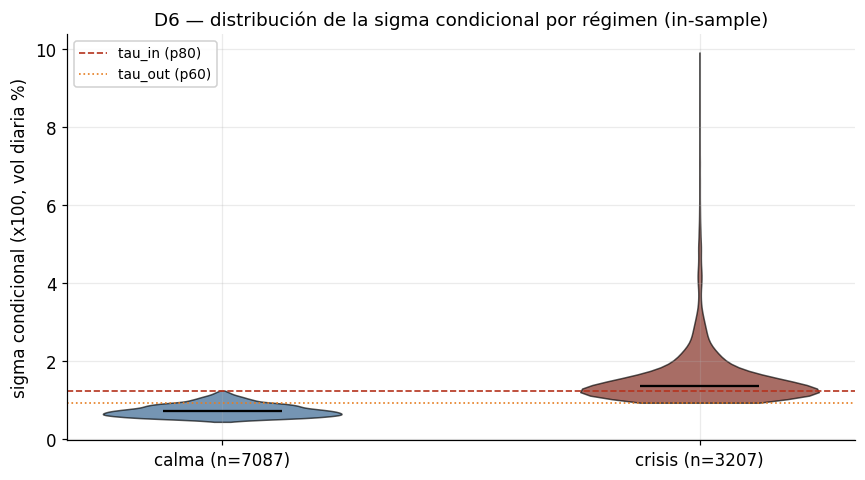

--- Sigma condicional in-sample por régimen ---
  régimen 0 [calma ]: mediana=0.716  media=0.742  máx=1.243  n=7087
  régimen 1 [CRISIS]: mediana=1.368  media=1.593  máx=9.911  n=3207
banda muerta de histéresis: tau_out=0.933  ->  tau_in=1.243


In [8]:
ax = viz.plot_distribution_by_regime(
    sigma_is, states_is, crisis_state=det_is.crisis_state,
    labels={0: 'calma', det_is.crisis_state: 'crisis'}, kind='violin',
    xlabel='sigma condicional (x100, vol diaria %)',
    title='D6 — distribución de la sigma condicional por régimen (in-sample)')
ax.axhline(det_is._tau_in, color=viz.C_CRISIS, ls='--', lw=1.1,
           label=f'tau_in (p{int(det_is.q_in*100)})')
ax.axhline(det_is._tau_out, color='#e67e22', ls=':', lw=1.1,
           label=f'tau_out (p{int(det_is.q_out*100)})')
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax.figure.savefig(RESULTS / 'd06_sigma_dist_by_regime.png', dpi=110, bbox_inches='tight'); plt.show()
print('--- Sigma condicional in-sample por régimen ---')
for k in sorted(int(s) for s in np.unique(states_is.values)):
    d = sigma_is[states_is.values == k]
    tag = 'CRISIS' if k == det_is.crisis_state else 'calma '
    print(f'  régimen {k} [{tag}]: mediana={np.median(d):.3f}  media={d.mean():.3f}  '
          f'máx={d.max():.3f}  n={len(d)}')
print(f'banda muerta de histéresis: tau_out={det_is._tau_out:.3f}  ->  tau_in={det_is._tau_in:.3f}')

<a id="sec4-2"></a>
### 4.2 Sigma condicional vs volatilidad realizada (¿mide lo que dice medir?)

La sigma del GARCH es una vol **esperada** (modelo); conviene contrastarla con una vol
**observada** *ex post*. Tomamos como proxy de volatilidad realizada la **desviación típica
móvil a 21 días** del retorno (escala ×100, misma unidad que la sigma) y la enfrentamos a la
sigma condicional. El panel superior superpone ambas series: la sigma del GARCH debe
**anticiparse o coincidir** con los picos de vol realizada, no ir por detrás (sería
look-ahead invertido). El panel inferior es el *scatter* sigma vs realizada coloreado por
régimen, con la diagonal 1:1: una nube alrededor de la diagonal y la correlación de Pearson
confirman que la señal que umbralizamos **mide de verdad volatilidad**, y que los días de
crisis (rojo) se agrupan en la esquina de alta-alta vol.

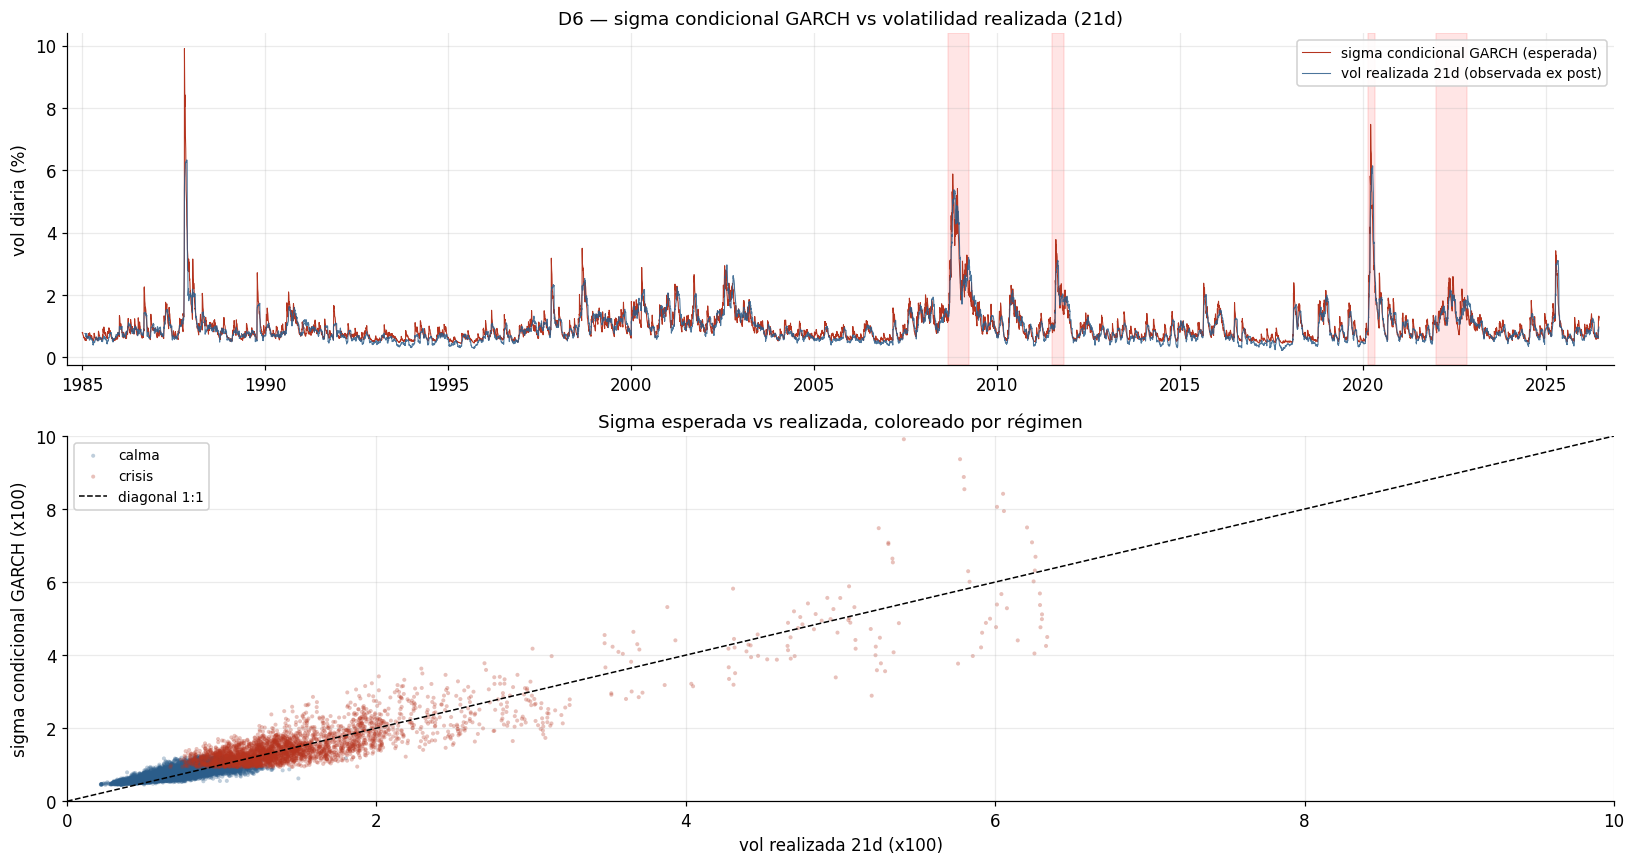

correlación(sigma condicional, vol realizada 21d) = 0.923  (alta = la sigma mide vol real)
sigma media en CRISIS=1.593  vs  CALMA=0.742


In [9]:
rv = (mkt * det_is.scale).rolling(21).std().reindex(sigma_is.index)   # vol realizada 21d (x100)
df_v = pd.DataFrame({'sigma': sigma_is, 'rv': rv, 'state': states_is}).dropna()

fig, (axT, axB) = plt.subplots(2, 1, figsize=(15, 8),
                               gridspec_kw={'height_ratios': [2.0, 2.2]})
axT.plot(sigma_is.index, sigma_is.values, color=viz.C_CRISIS, lw=0.7,
         label='sigma condicional GARCH (esperada)')
axT.plot(rv.index, rv.values, color=viz.C_LONG, lw=0.7, alpha=0.85,
         label='vol realizada 21d (observada ex post)')
for a, b in ev.CRISIS_WINDOWS.values():
    axT.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='red', alpha=0.10)
axT.set_ylabel('vol diaria (%)'); axT.margins(x=0.01)
axT.set_title('D6 — sigma condicional GARCH vs volatilidad realizada (21d)')
axT.legend(loc='upper right', fontsize=9, framealpha=0.9)

is_cri = (df_v['state'].values == det_is.crisis_state)
axB.scatter(df_v['rv'][~is_cri], df_v['sigma'][~is_cri], s=7, alpha=0.30,
            color=viz.C_LONG, edgecolors='none', label='calma')
axB.scatter(df_v['rv'][is_cri], df_v['sigma'][is_cri], s=7, alpha=0.30,
            color=viz.C_CRISIS, edgecolors='none', label='crisis')
lim = float(np.ceil(max(df_v['rv'].max(), df_v['sigma'].max())))
axB.plot([0, lim], [0, lim], color='black', lw=1.0, ls='--', label='diagonal 1:1')
axB.set_xlim(0, lim); axB.set_ylim(0, lim)
axB.set_xlabel('vol realizada 21d (x100)'); axB.set_ylabel('sigma condicional GARCH (x100)')
axB.set_title('Sigma esperada vs realizada, coloreado por régimen')
axB.legend(loc='upper left', fontsize=9, framealpha=0.9)
fig.tight_layout(); fig.savefig(RESULTS / 'd06_sigma_vs_realized.png', dpi=110, bbox_inches='tight'); plt.show()

corr = float(np.corrcoef(df_v['sigma'], df_v['rv'])[0, 1])
print(f'correlación(sigma condicional, vol realizada 21d) = {corr:.3f}  (alta = la sigma mide vol real)')
print(f'sigma media en CRISIS={df_v["sigma"][is_cri].mean():.3f}  vs  CALMA={df_v["sigma"][~is_cri].mean():.3f}')

<a id="sec5"></a>
## 5. S&P 500 coloreado por régimen (CAUSAL OOS)

Sombreado rojo = días clasificados **crisis** por el walk-forward causal. Líneas =
ventanas de crisis conocidas. Cubre 2008 y 2011 (OOS, a diferencia de D4).

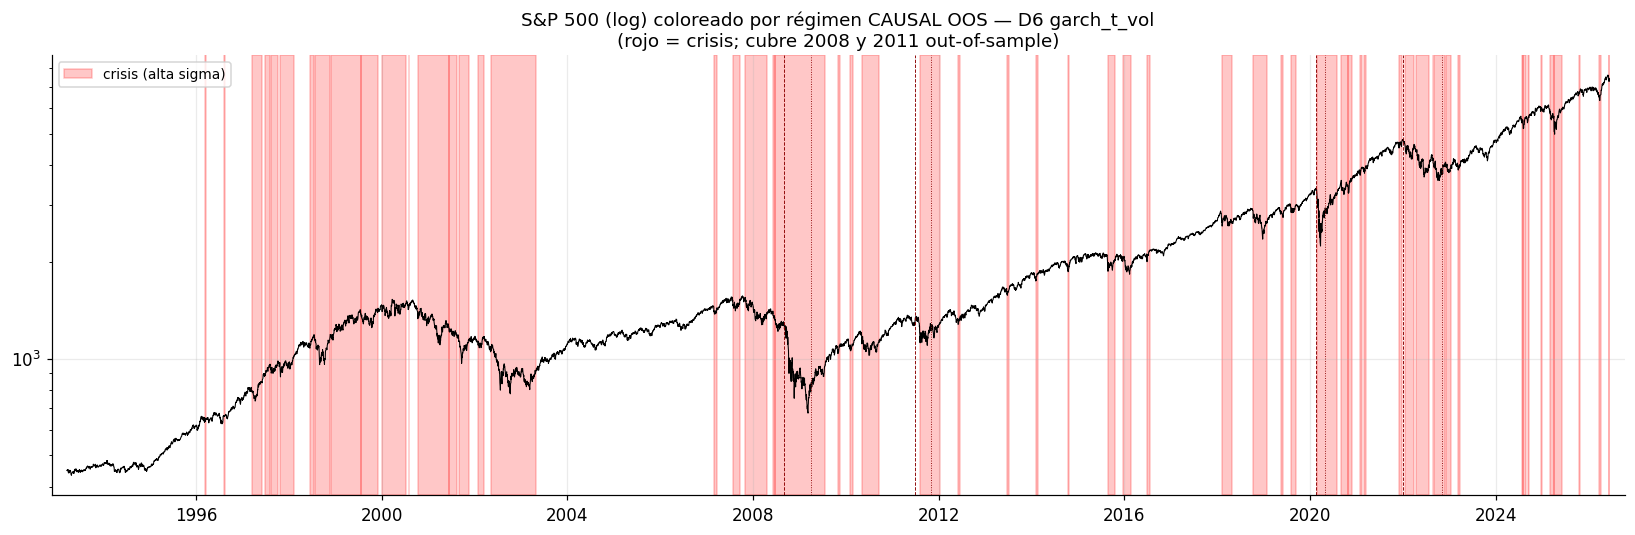

In [10]:
def shade_regime(ax, states, crisis_state, color='red', alpha=0.25):
    v = (states == crisis_state).astype(int).values; idx = states.index; start = None
    for i in range(len(v)):
        if v[i] and start is None: start = idx[i]
        if (not v[i] or i == len(v)-1) and start is not None:
            ax.axvspan(start, idx[i], color=color, alpha=alpha); start = None

fig, ax = plt.subplots(figsize=(15, 5))
px = sp500.reindex(states_c.index)
ax.plot(px.index, px.values, color='black', lw=0.7)
ax.set_yscale('log')
shade_regime(ax, states_c, det_is.crisis_state, color='red', alpha=0.22)
for a, b in ev.CRISIS_WINDOWS.values():
    ax.axvline(pd.Timestamp(a), color='darkred', ls='--', lw=0.6); ax.axvline(pd.Timestamp(b), color='darkred', ls=':', lw=0.6)
ax.set_title('S&P 500 (log) coloreado por régimen CAUSAL OOS — D6 garch_t_vol\n(rojo = crisis; cubre 2008 y 2011 out-of-sample)')
ax.legend(handles=[Patch(color='red', alpha=0.22, label='crisis (alta sigma)')], loc='upper left')
ax.margins(x=0.01); fig.tight_layout()
fig.savefig(RESULTS / 'd06_sp500_regimes.png', dpi=110, bbox_inches='tight'); plt.show()

<a id="sec6"></a>
## 6. Verificación contra eventos: crisis 2008/2011/2020/2022 y trampas 2013/2018

La pregunta clave de la hipótesis CP2: como el GARCH reacciona el mismo día, **¿capta
las correcciones rápidas de 2013 y 2018** que el HMM gaussiano se perdía?

,tipo,cobertura_OOS
ventana,,
GFC_2008,crisis,100.0%
EuroDebt_2011,crisis,74.1%
COVID_2020,crisis,94.0%
Inflation_2022,crisis,80.4%
TaperTantrum_2013,trampa,11.3%
Selloff_Q4_2018,trampa,87.3%


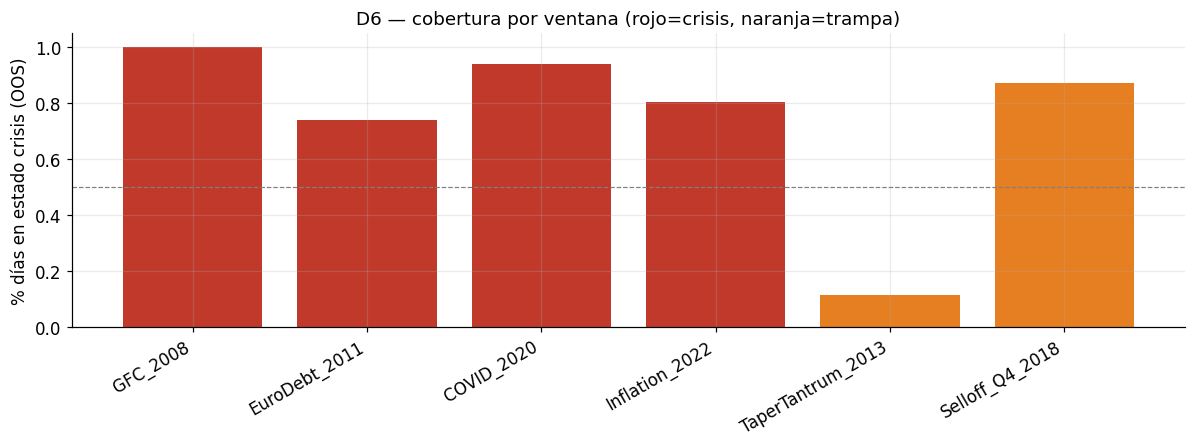

Lectura de la hipotesis CP2 (2013/2018):
  TaperTantrum_2013: 11.3%  -> apenas (evento de TIPOS/bonos, poca vol equity)
  Selloff_Q4_2018:   87.3%  -> CAPTADO (reaccion same-day, como predice CP2)


In [11]:
rows = []
for k in ev.CRISIS_WINDOWS:
    rows.append({'ventana': k, 'tipo': 'crisis', 'cobertura_OOS': res.crisis_coverage.get(k, float('nan'))})
for k in ev.FALSE_POSITIVE_WINDOWS:
    rows.append({'ventana': k, 'tipo': 'trampa', 'cobertura_OOS': res.false_alarm_in_fp.get(k, float('nan'))})
cmp = pd.DataFrame(rows).set_index('ventana')
display(cmp.style.format({'cobertura_OOS': '{:.1%}'}))

fig, ax = plt.subplots(figsize=(11, 4.2))
colors = ['#c0392b' if t == 'crisis' else '#e67e22' for t in cmp['tipo']]
ax.bar(cmp.index, cmp['cobertura_OOS'].values, color=colors)
ax.axhline(0.5, color='grey', ls='--', lw=0.8)
ax.set_ylabel('% días en estado crisis (OOS)')
ax.set_title('D6 — cobertura por ventana (rojo=crisis, naranja=trampa)')
ax.set_xticklabels(cmp.index, rotation=30, ha='right'); ax.set_ylim(0, 1.05)
fig.tight_layout(); fig.savefig(RESULTS / 'd06_coverage.png', dpi=110, bbox_inches='tight'); plt.show()

print('Lectura de la hipotesis CP2 (2013/2018):')
print(f'  TaperTantrum_2013: {res.false_alarm_in_fp["TaperTantrum_2013"]:.1%}  '
      f'-> {"CAPTADO" if res.false_alarm_in_fp["TaperTantrum_2013"]>0.4 else "apenas (evento de TIPOS/bonos, poca vol equity)"}')
print(f'  Selloff_Q4_2018:   {res.false_alarm_in_fp["Selloff_Q4_2018"]:.1%}  '
      f'-> {"CAPTADO (reaccion same-day, como predice CP2)" if res.false_alarm_in_fp["Selloff_Q4_2018"]>0.4 else "apenas"}')

<a id="sec7"></a>
## 7. Timeline de régimen y duraciones (flickering)

Timeline causal OOS + histograma de duraciones de episodios. La histéresis + dwell debe
dar episodios largos (poco flickering).

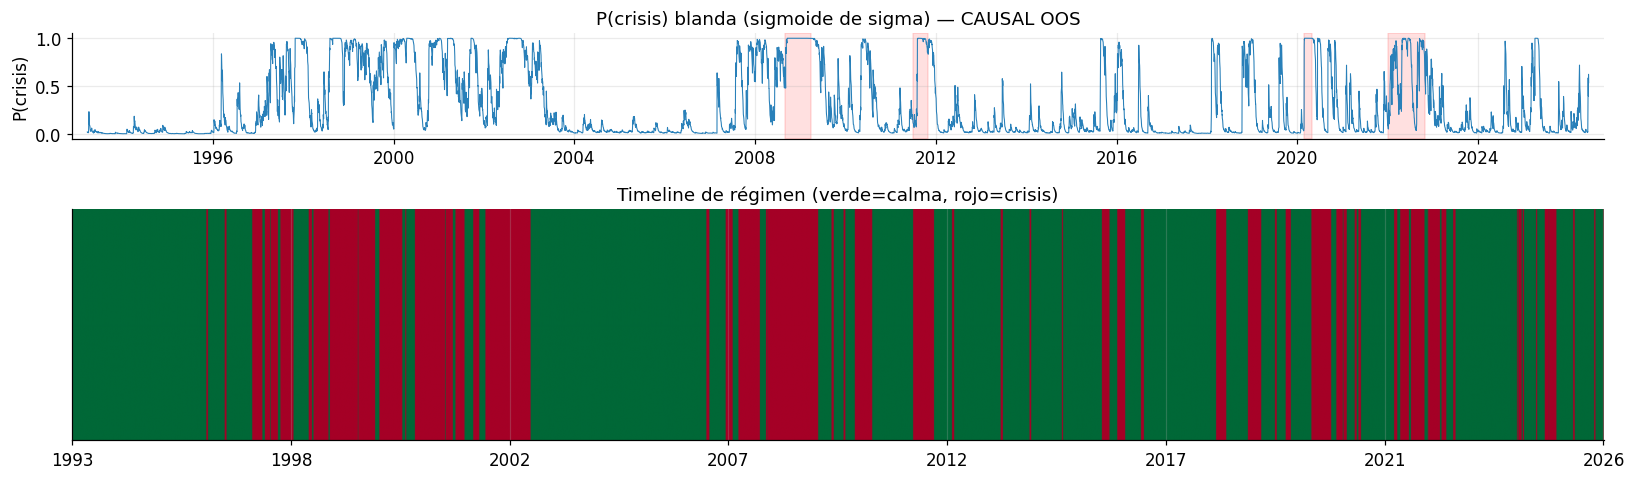

Episodios calma: n=59, dur media=93.9 d
Episodios crisis: n=59, dur media=46.4 d
switching_rate=0.0141  dur media global=70.2 d


In [12]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 4.5), gridspec_kw={'height_ratios': [1, 2.2]})
ax1.plot(p_c.index, p_c.values, color='#2980b9', lw=0.7); ax1.set_ylabel('P(crisis)')
for a, b in ev.CRISIS_WINDOWS.values(): ax1.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='red', alpha=0.12)
ax1.set_title('P(crisis) blanda (sigmoide de sigma) — CAUSAL OOS'); ax1.margins(x=0.01)
ax2.imshow(states_c.values.reshape(1, -1), aspect='auto', cmap='RdYlGn_r',
           extent=[0, len(states_c), 0, 1]); ax2.set_yticks([])
tk = np.linspace(0, len(states_c)-1, 8).astype(int)
ax2.set_xticks(tk); ax2.set_xticklabels([states_c.index[i].year for i in tk])
ax2.set_title('Timeline de régimen (verde=calma, rojo=crisis)')
fig.tight_layout(); fig.savefig(RESULTS / 'd06_timeline.png', dpi=110, bbox_inches='tight'); plt.show()

def episode_durations(states):
    v = states.values; out = {0: [], 1: []}; run = 1
    for i in range(1, len(v)):
        if v[i] == v[i-1]: run += 1
        else: out[int(v[i-1])].append(run); run = 1
    out[int(v[-1])].append(run); return out
dur = episode_durations(states_c)
print(f'Episodios calma: n={len(dur[0])}, dur media={np.mean(dur[0]):.1f} d')
print(f'Episodios crisis: n={len(dur[1])}, dur media={np.mean(dur[1]) if dur[1] else float("nan"):.1f} d')
print(f'switching_rate={res.switching_rate:.4f}  dur media global={res.mean_regime_duration:.1f} d')

<a id="sec8"></a>
## 8. Volcado de métricas a results/ (esquema canónico 32 columnas)

In [13]:
tbl = ev.results_table([res])
assert tbl.shape[1] == 32, f'esperaba 32 columnas (esquema canonico), hay {tbl.shape[1]}'
tbl.to_csv(RESULTS / 'metrics_06_garch_t_vol.csv', index=False)
print('Guardado results/metrics_06_garch_t_vol.csv  (1 fila,', tbl.shape[1], 'columnas)')

# NOTA (saneamiento Ola 0): este builder ya NO actualiza metrics_master.csv de forma
# incremental (leer-filtrar-concatenar provocaba condicion de carrera al correr builders
# en paralelo). Cada builder escribe SOLO su metrics_NN_*.csv; el master unificado se
# reconstruye de forma centralizada con:  python scripts/verify/_rebuild_master.py
display(tbl.T)

Guardado results/metrics_06_garch_t_vol.csv  (1 fila, 32 columnas)


,0
detector,garch_t_vol
n_states,2
ventana_eval,1993-03-23→2026-06-12 (n=8278)
oos_start,1993-03-23
oos_end,2026-06-12
n_oos,8278
false_alarm_rate,0.845142
switching_rate,0.014134
mean_regime_duration,70.152542
label_stability,0.999396


<a id="sec9"></a>
## 9. Conclusión D6 — ¿se cumple la hipótesis CP2?

**Hipótesis CP2:** *el GARCH no da estados tipados (se umbraliza sigma); es causal y
reacciona el mismo día → debería captar 2013 y 2018; univariante sobre equity.*

Veredicto (con los números de arriba):
- **Estados por umbral de sigma:** confirmado — 2 estados vía τ_in/τ_out + dwell sobre la
  sigma condicional; crisis = **alta sigma** (verificado, no invertido).
- **Causal y ventana larga:** OOS desde **1993** → **2008 y 2011 evaluables OOS**
  (cobertura GFC_2008 ≈ 100 %, EuroDebt_2011 ≈ 74 %), algo imposible para D4.
- **2018 (Q4):** **captado** (≈ 87 %) — la reacción same-day de la sigma sí dispara el
  régimen, como predice CP2 y a diferencia del HMM gaussiano (D4 ≈ 46 %).
- **2013 (taper tantrum):** **apenas** (≈ 11 %). Matiz a la hipótesis: el taper fue un
  shock de **tipos/bonos** con poca volatilidad realizada en el **equity**; un GARCH
  *univariante sobre el S&P 500* no ve ese estrés. Reacciona el mismo día… pero solo a
  la vol del activo que modela.
- **Persistencia:** episodios largos (dur ≈ 60 d, switching ≈ 0.016) → poco flickering,
  gracias a la histéresis+dwell y a la propia persistencia de la varianza GARCH.
- **Mecanismo justificado, no asumido:** las dos decisiones de diseño quedan validadas
  *visualmente* — la *news impact curve* (§1.1) muestra γ>0 (las caídas elevan más la vol:
  leverage de GJR) y el QQ-plot (§1.2) muestra que los residuos solo se alinean bajo la t,
  no bajo la Normal (colas pesadas → `dist='t'`). Además la sigma condicional correlaciona
  fuerte con la vol realizada (§4.2): la señal que umbralizamos mide volatilidad de verdad.

**Conclusión:** CP2 se cumple **parcialmente**. Acierta en lo estructural (causal,
same-day, capta 2008/2011/2018 que D4 no podía) pero la promesa "capta 2013 y 2018" solo
se verifica en **2018**: 2013, al ser un evento de tipos sin vol equity, se le escapa por
ser **univariante sobre equity** (la propia coletilla de la hipótesis). El precio de la
ventana larga + señal de vol pura es un `false_alarm_rate` alto (≈ 0.85): marca como
crisis muchos picos de vol fuera de las 4 ventanas etiquetadas (LTCM 1998, dotcom 2000–02,
flash-crash 2010, 2015–16, SVB 2023…), que son alta-vol reales pero no las crisis
canónicas del set.